Lab 24.1 – Scikit-Learn Pipelines
Goal: Build a reproducible end‑to‑end pipeline that:

imputes & scales numeric features,

imputes & one‑hot encodes categoricals,

trains a classifier,

evaluates with CV,

hyperparameter‑tunes via GridSearchCV,

saves & reloads the fitted pipeline,

predicts on raw (dict/CSV) data.

We’ll use the mixed‑type Titanic dataset from Seaborn.

0) Setup

In [1]:
# pip install scikit-learn pandas numpy seaborn matplotlib joblib
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, ConfusionMatrixDisplay, confusion_matrix
import joblib
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

1) Load data & select columns

In [2]:
df = sns.load_dataset('titanic').drop(columns=['alive'])
target = 'survived'
features = ['pclass','sex','age','sibsp','parch','fare','embarked','class','who','alone']

df = df[features + [target]].copy()
df[target] = df[target].astype(int)

X = df[features]
y = df[target]

2) Define preprocessing (no leakage)
Numeric: median impute → standardize

Categorical: most‑frequent impute → one‑hot (ignore unseen)

In [3]:
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

numeric_pre = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pre = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocess = ColumnTransformer([
    ('num', numeric_pre, num_cols),
    ('cat', categorical_pre, cat_cols)
])

3) Build the full Pipeline(preprocess → model) and train/test split

Hold‑out Accuracy: 0.832
Hold‑out ROC‑AUC: 0.869


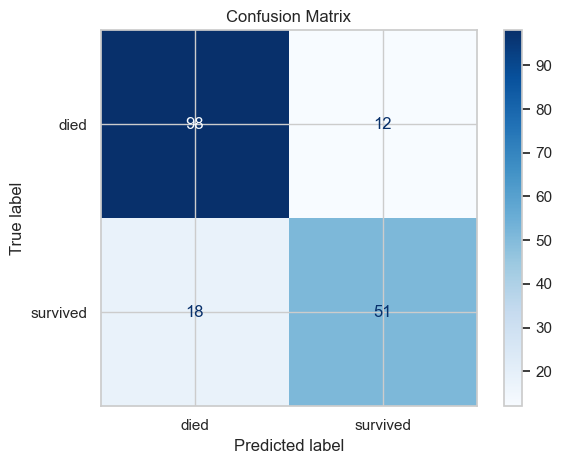

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

pipe = Pipeline([
    ('prep', preprocess),
    ('clf',  LogisticRegression(max_iter=2000))
])

pipe.fit(X_train, y_train)

y_pred  = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:,1]

print("Hold‑out Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Hold‑out ROC‑AUC:", round(roc_auc_score(y_test, y_proba), 3))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['died','survived']).plot(cmap='Blues')
plt.title('Confusion Matrix'); plt.tight_layout(); plt.show()

4) Cross‑validation with the same pipeline

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(pipe, X, y, cv=cv,
                        scoring={'acc':'accuracy','roc':'roc_auc'},
                        n_jobs=-1, return_train_score=False)
print("CV Accuracy  mean±std:", round(scores['test_acc'].mean(),3), "±", round(scores['test_acc'].std(),3))
print("CV ROC‑AUC   mean±std:", round(scores['test_roc'].mean(),3), "±", round(scores['test_roc'].std(),3))

CV Accuracy  mean±std: 0.822 ± 0.007
CV ROC‑AUC   mean±std: 0.866 ± 0.022


5) Hyperparameter tuning (grid over the pipeline)
Note how parameters are prefixed with their step name: clf__C, etc.

In [11]:
param_grid = {
    'clf__C': [0.1, 1, 3, 10],
 #   'clf__penalty': ['l2'], This will be default va
    'clf__solver': ['lbfgs']   # good with L2
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
).fit(X_train, y_train)

best = grid.best_estimator_
print("Best params:", grid.best_params_)
print("Tuned ROC‑AUC (CV):", round(grid.best_score_, 3))

# Test performance
proba = best.predict_proba(X_test)[:,1]
print("Tuned Hold‑out ROC‑AUC:", round(roc_auc_score(y_test, proba), 3))

Best params: {'clf__C': 0.1, 'clf__solver': 'lbfgs'}
Tuned ROC‑AUC (CV): 0.863
Tuned Hold‑out ROC‑AUC: 0.866


6) Use the pipeline on raw dicts (same preprocessing applied)

In [12]:
new_passengers = pd.DataFrame([
    {'pclass':3, 'sex':'male',   'age':22, 'sibsp':1, 'parch':0, 'fare':7.25,   'embarked':'S', 'class':'Third',  'who':'man',   'alone':False},
    {'pclass':1, 'sex':'female', 'age':38, 'sibsp':1, 'parch':0, 'fare':71.28,  'embarked':'C', 'class':'First', 'who':'woman', 'alone':False},
    {'pclass':2, 'sex':'female', 'age':27, 'sibsp':0, 'parch':0, 'fare':13.00,  'embarked':'S', 'class':'Second','who':'woman', 'alone':True},
    {'pclass':3, 'sex':'male',   'age':None,'sibsp':0,'parch':0, 'fare':8.05,   'embarked':None,'class':'Third', 'who':'man',   'alone':True},
])

pred_prob = best.predict_proba(new_passengers)[:,1]
pd.DataFrame({'survival_prob': pred_prob}).round(3)

,survival_prob
0,0.112
1,0.915
2,0.785
3,0.118


7) Save & reload the entire pipeline

In [13]:
joblib.dump(best, 'titanic_pipe.joblib')
loaded = joblib.load('titanic_pipe.joblib')
np.allclose(loaded.predict_proba(X_test)[:,1], best.predict_proba(X_test)[:,1])

True

8) (Optional) Swap model without changing preprocessing
Try a tree (insensitive to scaling) just by replacing the clf step.

In [14]:
from sklearn.ensemble import RandomForestClassifier
rf_pipe = Pipeline([
    ('prep', preprocess),
    ('clf',  RandomForestClassifier(n_estimators=400, random_state=0, n_jobs=-1))
])
rf_scores = cross_validate(rf_pipe, X, y, cv=cv, scoring={'acc':'accuracy','roc':'roc_auc'})
rf_scores['test_roc'].mean()

np.float64(0.8720447968504587)

9) (Optional) Add a ColumnTransformer branch for text (sketch)
If you have a free‑text column later, you can add TfidfVectorizer as another transformer and combine with numeric/categorical branches (using make_column_selector). The ColumnTransformer will horizontally stack outputs before the model.

In [15]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Load Titanic Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Select features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# 2. Define Transformers

# Numeric Branch: Impute missing values, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Branch: Impute missing values, then OneHotEncode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Text Branch: Convert text to TF-IDF features
# We limit max_features to keep the dimensionality reasonable for this dataset
text_transformer = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=50))
])

# 3. Create the ColumnTransformer
# We use make_column_selector for numeric types.
# We specify categorical and text columns explicitly to prevent overlap 
# (since 'Name', 'Sex', and 'Ticket' are all objects/strings).
preprocessor = ColumnTransformer(
    transformers=[
        # Branch 1: Numeric
        ('num', numeric_transformer, make_column_selector(dtype_include=np.number)),
        
        # Branch 2: Categorical (Explicitly selecting Sex and Embarked)
        ('cat', categorical_transformer, ['Sex', 'Embarked']),
        
        # Branch 3: Text (Targeting the 'Name' column)
        # Note: Passing 'Name' as a string (not a list) ensures TfidfVectorizer receives a 1D Series
        ('text', text_transformer, 'Name')
    ],
    remainder='drop' # Drop columns not specified (like Ticket or Cabin)
)

# 4. Bundle into a full Model Pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 5. Train and Evaluate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
score = model.score(X_test, y_test)

print(f"Model Accuracy with Text Features: {score:.4f}")


Model Accuracy with Text Features: 0.8212


Using Titanic dataset Replace the model with XGBClassifier or HistGradientBoostingClassifier (keep the same prep). Tune 2–3 hyperparameters via GridSearchCV; compare ROC‑AUC to Logistic Regression.


In [18]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score

# 1. Load Titanic Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Drop 'PassengerId' so the model doesn't learn from row IDs
X = df.drop(['Survived', 'PassengerId'], axis=1)
y = df['Survived']

# 2. Define Transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

text_transformer = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=50))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, make_column_selector(dtype_include=np.number)),
        ('cat', categorical_transformer, ['Sex', 'Embarked']),
        ('text', text_transformer, 'Name')
    ],
    remainder='drop'
)

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# Model A: Logistic Regression (Baseline)
# ---------------------------------------------------------
logreg_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

logreg_pipe.fit(X_train, y_train)
y_pred_logreg = logreg_pipe.predict_proba(X_test)[:, 1]
auc_logreg = roc_auc_score(y_test, y_pred_logreg)

# ---------------------------------------------------------
# Model B: HistGradientBoostingClassifier (Tuned)
# ---------------------------------------------------------

# Helper function to convert sparse matrix to dense safely
def to_dense(X):
    # Check if X has a toarray method (is sparse), otherwise return as is
    return X.toarray() if hasattr(X, "toarray") else X

hgb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    # Convert sparse output (from Tfidf/OneHot) to dense for HistGradientBoosting
    ('to_dense', FunctionTransformer(to_dense, accept_sparse=True)), 
    ('classifier', HistGradientBoostingClassifier(random_state=42))
])

# Define Hyperparameters to tune
param_grid = {
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__max_iter': [100, 200],
    'classifier__max_depth': [3, 5, None]
}

# Run GridSearchCV
grid_search = GridSearchCV(
    hgb_pipe, 
    param_grid, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Get best model and predictions
best_model = grid_search.best_estimator_
y_pred_hgb = best_model.predict_proba(X_test)[:, 1]
auc_hgb = roc_auc_score(y_test, y_pred_hgb)

# ---------------------------------------------------------
# Results Comparison
# ---------------------------------------------------------
print(f"--- Baseline: Logistic Regression ---")
print(f"ROC-AUC: {auc_logreg:.4f}")

print(f"\n--- Tuned: HistGradientBoostingClassifier ---")
print(f"Best Params: {grid_search.best_params_}")
print(f"ROC-AUC: {auc_hgb:.4f}")

if auc_hgb > auc_logreg:
    print(f"\nResult: Boosting improved ROC-AUC by {auc_hgb - auc_logreg:.4f}")
else:
    print(f"\nResult: Logistic Regression performed better or equal.")


--- Baseline: Logistic Regression ---
ROC-AUC: 0.8829

--- Tuned: HistGradientBoostingClassifier ---
Best Params: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__max_iter': 200}
ROC-AUC: 0.8714

Result: Logistic Regression performed better or equal.


Ablation: Remove class and who from features, re‑fit the tuned pipeline, and report how much ROC‑AUC drops—are those columns redundant with others (e.g., pclass, sex)?

In [19]:
from sklearn.base import clone

# 1. Define features to remove
# Note: 'class' and 'who' are typically found in the Seaborn version of Titanic.
# We use errors='ignore' so this runs even if you are using the standard CSV 
# where these columns might not exist.
features_to_drop = ['class', 'who']

X_train_ablated = X_train.drop(columns=features_to_drop, errors='ignore')
X_test_ablated = X_test.drop(columns=features_to_drop, errors='ignore')

# 2. Clone the best model configuration
# This creates a new, unfitted instance of the pipeline with the same parameters
model_ablation = clone(best_model)

# 3. Re-fit on the ablated data
print(f"Training model without features: {features_to_drop}...")
model_ablation.fit(X_train_ablated, y_train)

# 4. Evaluate
y_pred_ablated = model_ablation.predict_proba(X_test_ablated)[:, 1]
auc_ablated = roc_auc_score(y_test, y_pred_ablated)

# 5. Report Results
drop_amount = auc_hgb - auc_ablated

print(f"\n--- Ablation Study Results ---")
print(f"Original ROC-AUC: {auc_hgb:.4f}")
print(f"Ablated ROC-AUC:  {auc_ablated:.4f}")
print(f"Performance Drop: {drop_amount:.4f}")

if drop_amount <= 0.001:
    print("\nConclusion: The removed features were redundant or not used by the model.")
else:
    print("\nConclusion: The removed features contained unique, useful information.")


Training model without features: ['class', 'who']...

--- Ablation Study Results ---
Original ROC-AUC: 0.8714
Ablated ROC-AUC:  0.8714
Performance Drop: 0.0000

Conclusion: The removed features were redundant or not used by the model.


Build a regression pipeline on California Housing: numeric imputer+scaler → Ridge; perform GridSearchCV over alpha, and save the pipeline.

In [20]:
import joblib
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Data
# The target variable is the median house value for California districts,
# expressed in hundreds of thousands of dollars ($100,000).
data = fetch_california_housing()
X, y = data.data, data.target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Build the Pipeline
# Even though fetch_california_housing is clean, the Imputer ensures 
# the pipeline is robust against missing values in future production data.
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('regressor', Ridge())
])

# 3. Define Hyperparameters for GridSearchCV
# We tune 'alpha' (regularization strength).
param_grid = {
    'regressor__alpha': [0.1, 1.0, 10.0, 100.0, 200.0]
}

# 4. Perform Grid Search
# We use negative mean squared error for scoring so that higher is better 
# (GridSearchCV convention), though we will convert it back to RMSE for reporting.
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

print("Training pipeline with GridSearchCV...")
grid_search.fit(X_train, y_train)

# 5. Evaluate the Best Model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n--- Results ---")
print(f"Best Alpha: {grid_search.best_params_['regressor__alpha']}")
print(f"Test RMSE:  {rmse:.4f}")
print(f"Test R^2:   {r2:.4f}")

# 6. Save the Pipeline
filename = 'california_ridge_pipeline.pkl'
joblib.dump(best_model, filename)
print(f"\nPipeline saved to {filename}")


Training pipeline with GridSearchCV...

--- Results ---
Best Alpha: 0.1
Test RMSE:  0.7456
Test R^2:   0.5758

Pipeline saved to california_ridge_pipeline.pkl
